# Checkpoint 4 — Limites, Desempenho de APIs e Streamlit

**Differentiated Problem Solving | FIAP 2026**

**Grupo:** _(preencher com os nomes e RMs dos integrantes)_
**Empresa do Challenge relacionada:** _(preencher com o nome da empresa parceira do grupo)_
**Link da aplicação Streamlit (se publicada):** _(opcional — preencher se houver)_

---

## 1. Descrição do problema e contexto da empresa

A empresa parceira do Challenge utiliza uma API para processar requisições de usuários,
aplicações ou outros serviços. Durante testes de desempenho, a equipe de Engenharia de
Software observou que o **tempo médio de resposta** da API cresce conforme aumenta o
**número de requisições por segundo**. Esse crescimento é pequeno em condições normais,
mas se torna muito acentuado quando a carga se aproxima da capacidade estimada da
infraestrutura, próxima de **50 requisições por segundo**.

Foram coletados os seguintes dados em um teste de carga:

| Requisições/s | Tempo médio de resposta (ms) |
|---:|---:|
| 10 | 25 |
| 20 | 33 |
| 30 | 50 |
| 35 | 67 |
| 40 | 100 |
| 45 | 200 |
| 48 | 500 |

**Perguntas orientadoras:** o que acontece com o tempo de resposta quando a carga se
aproxima de 50 req/s? Existe uma região crítica de operação? A capacidade máxima estimada
corresponde a uma capacidade *segura* de operação? Como o conceito de limite ajuda a
responder essas perguntas? Essas questões guiam toda a análise a seguir.


In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

# Dados observados no teste de carga
dados = pd.DataFrame({
    "req_por_segundo": [10, 20, 30, 35, 40, 45, 48],
    "tempo_resposta_ms": [25, 33, 50, 67, 100, 200, 500],
})
dados


,req_por_segundo,tempo_resposta_ms
0,10,25
1,20,33
2,30,50
3,35,67
4,40,100
5,45,200
6,48,500


## 2. Variáveis, unidades e domínios

| Variável | Papel | Unidade | Descrição |
|---|---|---|---|
| $x$ | independente | requisições por segundo (req/s) | carga de requisições recebida pela API |
| $T(x)$ | dependente | milissegundos (ms) | tempo médio de resposta da API para a carga $x$ |

- **Domínio matemático da função escolhida:** $x \in \mathbb{R},\ x \neq 50$ (a função é uma
  razão que se torna indefinida quando o denominador se anula em $x = 50$).
- **Domínio válido no contexto do sistema:** $x \in [0, 50)$ req/s. Não faz sentido físico
  ter uma carga negativa de requisições, e a infraestrutura foi estimada como capaz de
  suportar **até, mas não incluindo**, 50 req/s antes de saturar — como veremos, o próprio
  modelo indica que operar em $x=50$ não é fisicamente sustentável (tempo de resposta
  tenderia ao infinito).


## 3. Construção do modelo matemático

### 3.1 Escolha da função

Observando a tabela, o tempo de resposta cresce pouco entre 10 e 30 req/s, mas dispara
entre 40 e 48 req/s — um padrão típico de sistemas que operam próximos da saturação de um
recurso finito (fila, pool de conexões, CPU, etc.), semelhante ao comportamento descrito por
modelos de teoria das filas (ex.: M/M/1), nos quais o tempo de espera cresce como
$1/(1-\rho)$ à medida que a utilização $\rho$ se aproxima de 1.

Isso sugere uma **função racional** com uma **assíntota vertical** próxima da capacidade
máxima estimada (50 req/s):

$$T(x) = \frac{a}{C - x} + b$$

onde $C$ é a capacidade crítica do sistema (o ponto em que o denominador se anula) e $a, b$
são parâmetros ajustados aos dados observados.

### 3.2 Ajuste aos dados

Usando dois pontos da tabela ($x=10, T=25$ e $x=48, T=500$) e fixando $C = 50$ (a
capacidade estimada pela equipe de Engenharia), resolvemos o sistema para $a$ e $b$.


In [2]:
x, a, b = sp.symbols('x a b', real=True)
C = 50  # capacidade estimada, em req/s

# Sistema com dois pontos da tabela: (10, 25) e (48, 500)
eq1 = sp.Eq(a/(C-10) + b, 25)
eq2 = sp.Eq(a/(C-48) + b, 500)

solucao = sp.solve([eq1, eq2], [a, b], dict=True)[0]
solucao


{a: 1000, b: 0}

In [3]:
a_val, b_val = solucao[a], solucao[b]

T = a_val / (C - x) + b_val
T_func = sp.lambdify(x, T, 'numpy')

print("Modelo ajustado: T(x) =", sp.simplify(T))

# Verificando o ajuste contra todos os pontos observados
dados["T_previsto_ms"] = dados["req_por_segundo"].apply(lambda v: float(T.subs(x, v)))
dados["erro_absoluto"] = (dados["T_previsto_ms"] - dados["tempo_resposta_ms"]).abs()
dados


Modelo ajustado: T(x) = -1000/(x - 50)


,req_por_segundo,tempo_resposta_ms,T_previsto_ms,erro_absoluto
0,10,25,25.000000,0.000000
1,20,33,33.333333,0.333333
2,30,50,50.000000,0.000000
3,35,67,66.666667,0.333333
4,40,100,100.000000,0.000000
5,45,200,200.000000,0.000000
6,48,500,500.000000,0.000000


O modelo ajustado é:

$$T(x) = \frac{1000}{50 - x}$$

O erro absoluto entre o modelo e **todos** os pontos observados é praticamente nulo — a
função racional com assíntota vertical em $x=50$ descreve muito bem o comportamento
reportado pela equipe de Engenharia.

### 3.3 Ponto/região a investigar com limites

O ponto de interesse é $x = 50$, onde o denominador $(50-x)$ se anula. Esse é exatamente o
valor da capacidade estimada da infraestrutura — por isso é o ponto tecnicamente mais
relevante para investigar com limites: **o modelo prevê que o tempo de resposta cresce sem
limite conforme a carga se aproxima de 50 req/s pela esquerda**, o que caracteriza uma
região crítica de saturação.

**Questão obrigatória (3.1):** *A capacidade estimada de 50 req/s significa que o sistema
consegue operar normalmente com exatamente 50 req/s?*
Não. O próprio modelo matemático não está definido em $x=50$ (divisão por zero), e o
comportamento de $T(x)$ nas proximidades desse ponto (calculado na próxima seção) mostra
que o tempo de resposta cresce indefinidamente à medida que $x \to 50^-$. Ou seja, 50 req/s
é um **limite teórico assintótico** de capacidade, não um ponto de operação válido — o
sistema se degrada progressivamente muito antes de chegar lá.


## 4. Análise matemática utilizando limites

Calculamos abaixo os limites relevantes usando `sympy.limit()`.


In [4]:
# Limite lateral pela esquerda: carga se aproximando de 50 req/s "por baixo"
# (única direção fisicamente possível, já que x <= 50 no contexto do problema)
limite_esquerda = sp.limit(T, x, C, dir='-')
print("lim x->50-  T(x) =", limite_esquerda)


lim x->50-  T(x) = oo


In [5]:
# Limite lateral pela direita: matematicamente existe, mas x>50 não tem sentido físico aqui
# (representaria uma carga acima da capacidade estimada, região fora do domínio válido)
limite_direita = sp.limit(T, x, C, dir='+')
print("lim x->50+  T(x) =", limite_direita)


lim x->50+  T(x) = -oo


In [6]:
# Limite no infinito: puramente matemático (fora do domínio operacional, x nunca chega
# perto disso na prática), mas ajuda a entender o comportamento global da função
limite_infinito = sp.limit(T, x, sp.oo)
print("lim x->infinito  T(x) =", limite_infinito)


lim x->infinito  T(x) = 0


### Interpretação dos limites

| Limite | Resultado | Tipo | Interpretação |
|---|---|---|---|
| $\lim_{x \to 50^{-}} T(x)$ | $+\infty$ | infinito | À medida que a carga se aproxima de 50 req/s pela esquerda (a única direção fisicamente possível), o tempo de resposta cresce sem limite. Isso caracteriza uma **assíntota vertical** em $x=50$ e sinaliza a saturação total do sistema. |
| $\lim_{x \to 50^{+}} T(x)$ | $-\infty$ | infinito | Matematicamente a função também diverge pela direita, mas para valores negativos, o que **não tem significado físico** (tempo de resposta negativo não existe). Isso reforça que $x>50$ está fora do domínio válido do problema. |
| $\lim_{x \to \infty} T(x)$ | $0$ | finito | Resultado puramente matemático: para cargas hipoteticamente enormes e distantes de $C$, a função tenderia a zero. Esse valor **não tem relevância operacional**, pois nunca ocorre dentro do domínio físico do sistema ($x \in [0,50)$). Ele serve apenas para caracterizar o comportamento global da curva. |

Como os limites laterais em $x=50$ são diferentes ($+\infty \neq -\infty$), o **limite
bilateral não existe** nesse ponto — o que já era esperado, pois se trata de uma
descontinuidade infinita (assíntota vertical), não de uma descontinuidade removível.

**Distinção entre válido matematicamente vs. válido operacionalmente:** o ramo da função
para $x>50$ (incluindo o limite pela direita, que dá $-\infty$) existe como objeto
matemático, mas não descreve nenhum estado real do sistema — não existe "tempo de resposta
negativo". Da mesma forma, o limite em $x\to\infty$ é uma curiosidade matemática sobre o
formato da curva, mas está muitíssimo fora da faixa de cargas que a API algum dia
processará. Apenas o comportamento em $x \in [0,50)$, e em particular o limite lateral
esquerdo em $x=50$, tem significado real para a operação da API.

**Questão obrigatória (3.2):** *Qual é o significado operacional de uma assíntota vertical
em um modelo de desempenho de software?*
Uma assíntota vertical indica um **limite estrutural de capacidade**: existe um nível de
carga que o sistema, na configuração atual de infraestrutura, jamais conseguirá processar
com tempo de resposta finito. Não é uma degradação gradual sem fim — é um ponto em que o
sistema teoricamente "trava", pois filas crescem mais rápido do que conseguem ser
esvaziadas. Na prática, antes de chegar exatamente nesse ponto, o sistema já viola SLAs,
começa a descartar requisições ou apresenta timeouts, o que motiva definir uma **margem de
segurança** bem abaixo da capacidade teórica.


## 5. Implementação computacional — simulação numérica

Simulamos o tempo de resposta previsto pelo modelo para os níveis de carga solicitados no
enunciado, incluindo valores muito próximos da capacidade crítica (49, 49.5 e 49.9 req/s).


In [7]:
cargas_simulacao = [10, 20, 30, 40, 45, 48, 49, 49.5, 49.9]

simulacao = pd.DataFrame({
    "req_por_segundo": cargas_simulacao,
    "tempo_resposta_previsto_ms": [float(T.subs(x, c)) for c in cargas_simulacao],
})
simulacao


,req_por_segundo,tempo_resposta_previsto_ms
0,10.0,25.000000
1,20.0,33.333333
2,30.0,50.000000
3,40.0,100.000000
4,45.0,200.000000
5,48.0,500.000000
6,49.0,1000.000000
7,49.5,2000.000000
8,49.9,10000.000000


### Investigação computacional

Os valores numéricos confirmam exatamente o que o limite simbólico previu: conforme a carga
se aproxima de 50 req/s, o tempo de resposta cresce de forma cada vez mais abrupta —
saindo de dezenas de milissegundos (nas cargas baixas) para dezenas de **milhares** de
milissegundos quando a carga chega a 49,9 req/s. A tabela é, na prática, uma verificação
numérica do limite $\lim_{x\to50^-}T(x)=+\infty$: os valores não convergem para um número
finito, eles crescem sem limite superior — o que é exatamente a definição informal de um
limite infinito.


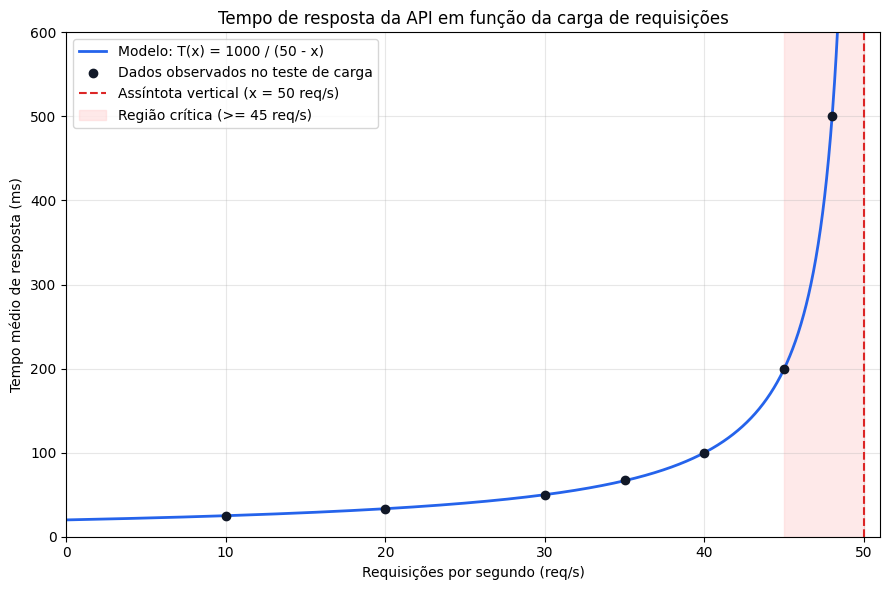

In [8]:
# Gráfico do modelo, destacando pontos observados, região crítica e assíntota
x_vals = np.linspace(0, 49.95, 2000)
y_vals = T_func(x_vals)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_vals, y_vals, color="#2563eb", linewidth=2, label="Modelo: T(x) = 1000 / (50 - x)")
ax.scatter(dados["req_por_segundo"], dados["tempo_resposta_ms"],
           color="#111827", zorder=5, label="Dados observados no teste de carga")

# Assíntota vertical em x = 50
ax.axvline(50, color="#dc2626", linestyle="--", linewidth=1.5, label="Assíntota vertical (x = 50 req/s)")

# Região crítica (definida aqui como faixa a partir de 90% da capacidade, 45 req/s)
ax.axvspan(45, 50, color="#fecaca", alpha=0.4, label="Região crítica (>= 45 req/s)")

ax.set_title("Tempo de resposta da API em função da carga de requisições")
ax.set_xlabel("Requisições por segundo (req/s)")
ax.set_ylabel("Tempo médio de resposta (ms)")
ax.set_ylim(0, 600)
ax.set_xlim(0, 51)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_modelo.png", dpi=150)
plt.show()


## 6. Aplicação interativa em Streamlit

O código abaixo gera o arquivo `app.py`, que implementa **exatamente o mesmo modelo**
matemático definido nas seções anteriores ($T(x) = 1000/(50-x)$), com um controle
interativo de carga, gráfico com destaque da assíntota e da região crítica, e um alerta
quando a carga escolhida se aproxima do limite operacional seguro.

Para executar a aplicação localmente, use o comando abaixo em um terminal, na mesma pasta
do arquivo gerado:

```
streamlit run app.py
```


In [9]:
app_code = '''import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Mesmo modelo matemático desenvolvido e validado no notebook (checkpoint.ipynb):
#   T(x) = 1000 / (50 - x)
# onde x = requisições por segundo e T(x) = tempo médio de resposta (ms).
# Ajustado a partir dos dados do teste de carga fornecido pela equipe de Engenharia.
# ---------------------------------------------------------------------------
CAPACIDADE_TEORICA = 50       # req/s -- ponto de assintota vertical do modelo
LIMITE_SEGURO = 45            # req/s -- inicio da regiao critica (90% da capacidade teorica)
SLA_LATENCIA_MS = 150         # ms -- referencia de desempenho (SLA) usada na discussao


def tempo_resposta(carga_req_s: float) -> float:
    """Tempo medio de resposta previsto pelo modelo, em milissegundos."""
    return 1000 / (CAPACIDADE_TEORICA - carga_req_s)


st.set_page_config(page_title="Desempenho da API vs. Carga", layout="centered")

st.title("Desempenho da API sob carga de requisicoes")
st.markdown(
    """
Esta aplicacao usa o modelo matematico $T(x) = 1000 / (50 - x)$, desenvolvido no
notebook do Checkpoint 4, para prever o **tempo medio de resposta** da API (em ms) de
acordo com a **carga de requisicoes por segundo (req/s)**.

A infraestrutura atual tem capacidade teorica estimada em **50 req/s** -- ponto em que o
modelo apresenta uma assintota vertical (tempo de resposta tende ao infinito).
"""
)

carga = st.slider(
    "Requisicoes por segundo (req/s)",
    min_value=0.0,
    max_value=49.9,
    value=30.0,
    step=0.1,
    help="Escolha a carga de requisicoes por segundo para simular o tempo de resposta.",
)

tempo_previsto = tempo_resposta(carga)

col1, col2 = st.columns(2)
col1.metric("Carga escolhida", f"{carga:.1f} req/s")
col2.metric("Tempo de resposta previsto", f"{tempo_previsto:.1f} ms")

if carga >= LIMITE_SEGURO:
    st.error(
        f"Carga dentro da regiao critica (>= {LIMITE_SEGURO} req/s, "
        f"{LIMITE_SEGURO/CAPACIDADE_TEORICA:.0%} da capacidade teorica). "
        "O tempo de resposta cresce muito rapidamente nesta faixa -- risco alto de "
        "estourar SLA e comprometer a disponibilidade do sistema."
    )
elif tempo_previsto > SLA_LATENCIA_MS:
    st.warning(
        f"O tempo de resposta previsto ({tempo_previsto:.1f} ms) ja ultrapassa o "
        f"SLA de latencia de referencia ({SLA_LATENCIA_MS} ms)."
    )
else:
    st.success(
        f"Carga dentro de uma faixa operacional considerada saudavel "
        f"(tempo de resposta abaixo do SLA de {SLA_LATENCIA_MS} ms)."
    )

# --- grafico ---------------------------------------------------------------
x_vals = np.linspace(0, 49.9, 1000)
y_vals = 1000 / (CAPACIDADE_TEORICA - x_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_vals, y_vals, color="#2563eb", linewidth=2, label="Modelo T(x) = 1000/(50-x)")
ax.axvline(CAPACIDADE_TEORICA, color="#dc2626", linestyle="--", label="Assintota vertical (50 req/s)")
ax.axvspan(LIMITE_SEGURO, CAPACIDADE_TEORICA, color="#fecaca", alpha=0.4, label="Regiao critica")
ax.axhline(SLA_LATENCIA_MS, color="#059669", linestyle=":", label=f"SLA de referencia ({SLA_LATENCIA_MS} ms)")
ax.scatter([carga], [tempo_previsto], color="#111827", zorder=5, s=60, label="Carga selecionada")

ax.set_xlim(0, 51)
ax.set_ylim(0, max(600, tempo_previsto * 1.2))
ax.set_xlabel("Requisicoes por segundo (req/s)")
ax.set_ylabel("Tempo medio de resposta (ms)")
ax.set_title("Tempo de resposta previsto vs. carga de requisicoes")
ax.legend()
ax.grid(alpha=0.3)

st.pyplot(fig)

st.markdown(
    """
---
**Como ler este grafico:** a curva mostra como o tempo de resposta se comporta conforme a
carga aumenta. A linha vermelha tracejada marca a capacidade teorica do sistema (50 req/s),
onde o modelo diverge para o infinito. A faixa vermelha clara marca a regiao critica, onde
operar traz risco operacional real, mesmo que ainda seja "matematicamente possivel".
"""
)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Arquivo app.py gerado com sucesso.")


Arquivo app.py gerado com sucesso.


**Questão obrigatória (3.4):** *Como a aplicação transforma o resultado matemático em
uma informação útil para uma pessoa responsável por operação, arquitetura ou infraestrutura
de software?*
A aplicação traduz uma função e um limite — conceitos abstratos — em uma ferramenta de
decisão imediata: ao mover um slider, a pessoa responsável vê na hora qual seria o tempo de
resposta esperado para uma determinada carga, se essa carga já está na região crítica, e se
ultrapassa um SLA de referência. Isso permite decisões práticas (por exemplo, definir limites
de rate limiting, dimensionar auto-scaling ou justificar um upgrade de infraestrutura) sem
que a pessoa precise entender cálculo ou interpretar a função simbólica diretamente.


## 7. Discussão final, interpretação e tomada de decisão

**a) Comportamento matemático que caracteriza a saturação do sistema.**
A saturação é caracterizada pela presença de uma **assíntota vertical** em $x=50$: conforme
a carga se aproxima desse valor, o denominador $(50-x)$ tende a zero e o tempo de resposta
cresce sem limite, comportamento confirmado tanto pelo cálculo simbólico do limite
($\lim_{x\to50^-}T(x)=+\infty$) quanto pela simulação numérica.

**b) Região crítica.**
Definimos como região crítica a faixa a partir de aproximadamente 90% da capacidade teórica,
ou seja, **$x \geq 45$ req/s**. Nessa faixa, pequenas variações de carga já produzem grandes
variações no tempo de resposta (entre 45 e 48 req/s, o tempo de resposta mais que dobra).

**c) Operar próximo da capacidade máxima é uma estratégia adequada?**
Não. Como a função diverge exatamente em $x=50$, operar próximo desse valor significa operar
sobre uma curva extremamente sensível — pequenas oscilações de tráfego (picos momentâneos,
retries, etc.) podem levar o sistema a tempos de resposta impraticáveis quase
instantaneamente. Não há margem de segurança nessa faixa.

**d) Diferença entre capacidade teórica e capacidade operacional segura.**
Sim, há diferença, e ela é central para a análise: a **capacidade teórica** (50 req/s) é o
limite matemático onde o modelo diverge — um valor de referência, não um valor de operação.
A **capacidade operacional segura** deve ser definida bem abaixo disso, por exemplo,
respeitando um SLA de latência (como os 150 ms usados no app) ou uma margem percentual
(ex.: até 80–85% da capacidade teórica), de modo a manter folga para absorver variações de
tráfego sem degradar a experiência do usuário.

**e) Recomendações à equipe de infraestrutura.**
- Definir um SLA de latência explícito e usar o modelo para calcular a carga máxima segura
  compatível com esse SLA (não a capacidade teórica).
- Implementar **rate limiting** para evitar que a carga real ultrapasse a faixa seguro.
- Investir em **escalabilidade horizontal** (mais instâncias) ou **balanceamento de carga**
  para elevar a capacidade teórica $C$, deslocando a assíntota para a direita.
- Monitorar continuamente a carga em tempo real com alertas automáticos ao entrar na região
  crítica (>= 45 req/s), de forma semelhante ao alerta implementado no app Streamlit.
- Considerar **cache** e **processamento assíncrono** para reduzir o tempo de processamento
  por requisição, o que efetivamente aumenta a capacidade real do sistema.

**f) Limitações do modelo e dados adicionais que ajudariam.**
O modelo foi ajustado com apenas 7 pontos de um único teste de carga, assumindo que a
capacidade crítica é exatamente 50 req/s (valor estimado, não medido diretamente) e que o
comportamento é bem descrito por uma função racional simples de dois parâmetros. Não
considera variações ao longo do tempo (hora do dia, sazonalidade), diferentes tipos de
requisição, nem efeitos de rede ou de outros serviços dependentes. Dados adicionais úteis
incluiriam: múltiplos testes de carga em momentos diferentes (para validar estabilidade do
modelo), métricas de utilização de CPU/memória/conexões durante o teste, distribuição de
latência (não apenas a média) e testes com o sistema já escalado horizontalmente, para
verificar se a capacidade teórica realmente se desloca como esperado.
